In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

In [2]:
data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:344
Number of data points for zr034:323


In [3]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx])
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat()


In [4]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count



In [5]:
x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{res.x[:4]/np.linalg.norm(res.x[:4])}")
print(f"q_cm_zl_a:{res.x[4:8]/np.linalg.norm(res.x[4:8])}")
print(f"q_cm_zl_b:{res.x[8:12]/np.linalg.norm(res.x[8:12])}")
print(f"q_cm_zr_a:{res.x[12:16]/np.linalg.norm(res.x[12:16])}")
print(f"q_cm_zr_b:{res.x[16:20]/np.linalg.norm(res.x[16:20])}")

KeyboardInterrupt: 

In [ ]:
rot_rrp = R.from_quat(res.x[:4])
rot_rrp.as_matrix()

array([[ 9.99996802e-01,  2.52092992e-03,  2.01597040e-04],
       [-2.52091835e-03,  9.99996821e-01, -5.76411691e-05],
       [-2.01741709e-04,  5.71327751e-05,  9.99999978e-01]])

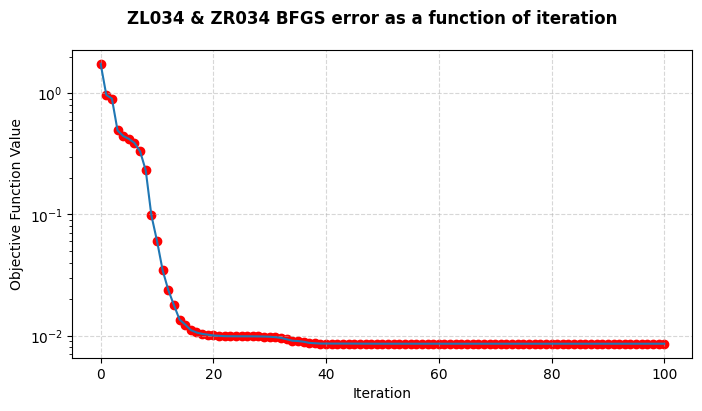

In [ ]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

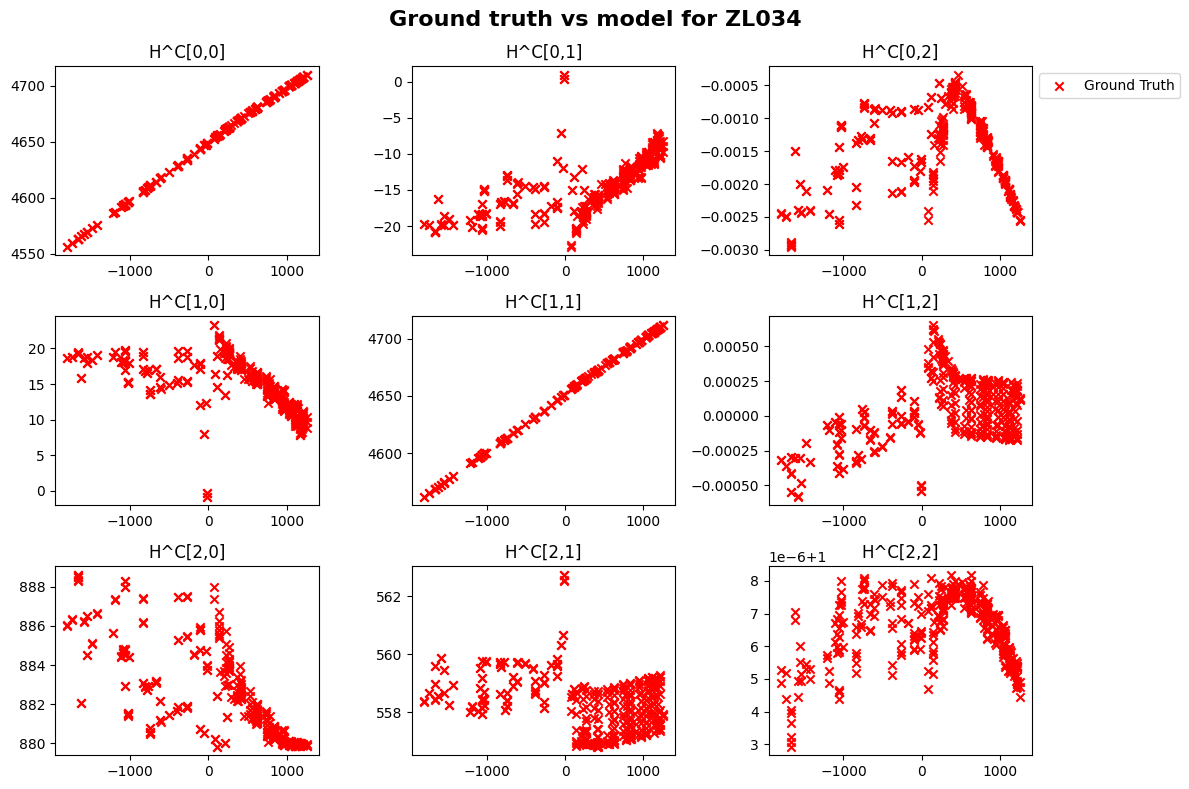

In [ ]:
# See how well the above fit is

q_rrp = np.array(res.x[:4])

q_cm_zl_a = np.array(res.x[4:8])
q_cm_zl_b = np.array(res.x[8:12])

q_cm_zr_a = np.array(res.x[12:16])
q_cm_zr_b = np.array(res.x[16:20])


# Compute H_r from model
H_c_model = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    # ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C[{r},{c}]")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

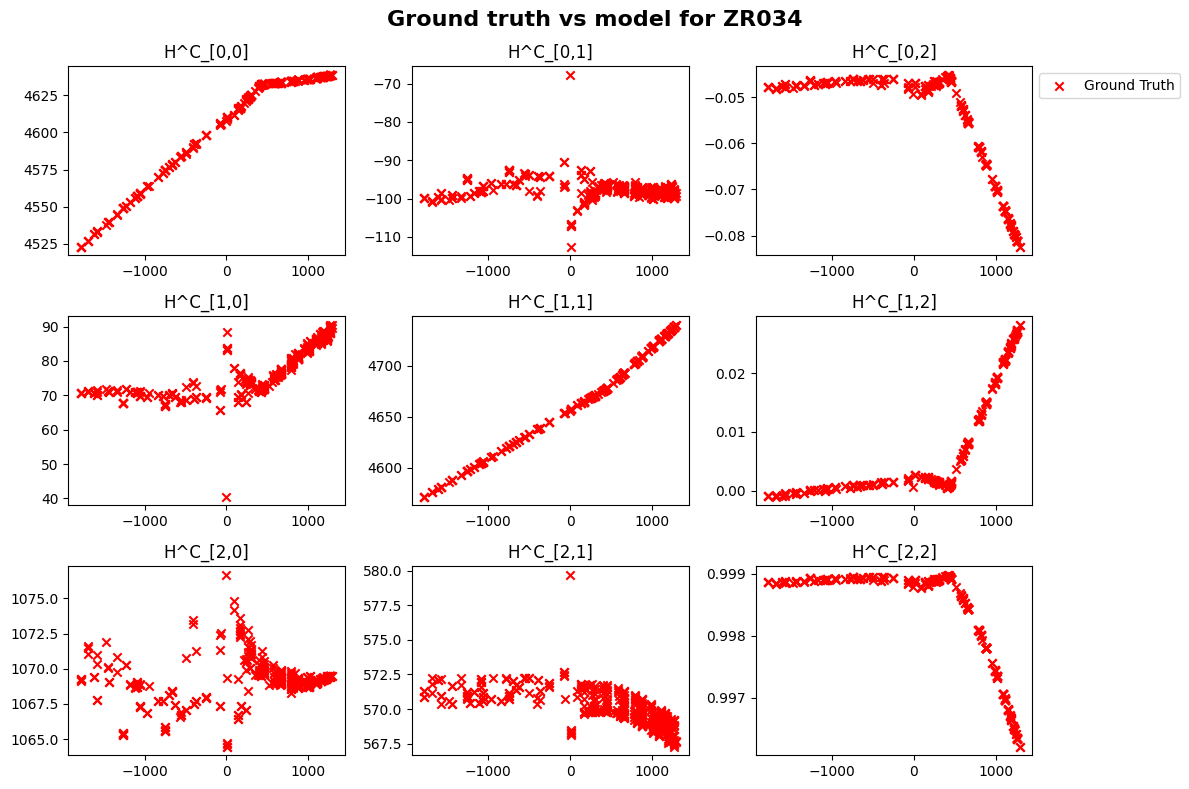

In [ ]:
# Compute H_r from model
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C_[{r},{c}]")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

# Constrain Minimization

Here we will enforce the predicted $H^c$ to be to have the entries at (0,1), (0,2), (1,2) to be close to zero by using the lagrangian multiplier method. 

In [16]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  gamma = 1
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      # distance between data and model
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      dist_qData_qModel = dist_q(q_rc_data, q_rc_model)
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      dist_qData_qModel = dist_q(q_rc_data, q_rc_model)

    else:
      continue
    
    count += 1

    # add the slack term
    slack = 0
    R_rc = R.from_quat(q_rc_model).as_matrix()
    H_r_data = get_H_r_data(i, data034)
    slack += R_rc[0,:] @ H_r_data[:,1]
    slack += R_rc[0,:] @ H_r_data[:,2]
    slack += R_rc[1,:] @ H_r_data[:,2]

    total_dist += gamma * max(0, slack) + dist_qData_qModel

  return total_dist/count

x0 = [0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,]
res = minimize(obj, x0, method="BFGS", options={"return_all":True})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{res.x[:4]/np.linalg.norm(res.x[:4])}")
print(f"q_cm_zl_a:{res.x[4:8]/np.linalg.norm(res.x[4:8])}")
print(f"q_cm_zl_b:{res.x[8:12]/np.linalg.norm(res.x[8:12])}")
print(f"q_cm_zr_a:{res.x[12:16]/np.linalg.norm(res.x[12:16])}")
print(f"q_cm_zr_b:{res.x[16:20]/np.linalg.norm(res.x[16:20])}")

Final function:2.233309
Final Jacobian:0.683484
q_rrp:[ 0.57773851  0.44765551  0.68226109 -0.01850858]
q_cm_zl_a:[ 0.50086683  0.50010197  0.49930656 -0.49972333]
q_cm_zl_b:[ 0.59304021  0.69615514  0.00097959 -0.40456194]
q_cm_zr_a:[ 0.50001856  0.50047934  0.49959147 -0.49991023]
q_cm_zr_b:[ 0.64834333  0.69499873 -0.0483669  -0.30706406]


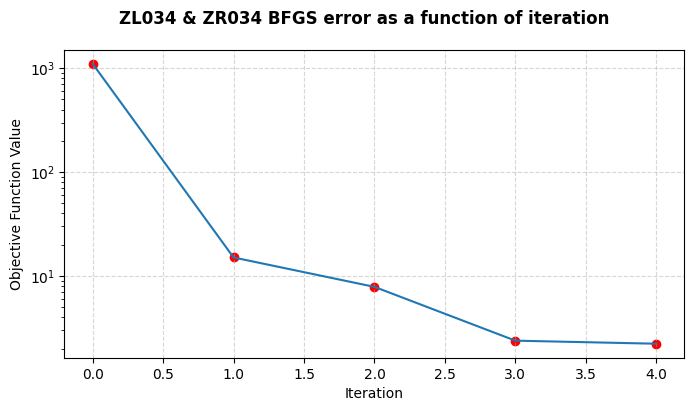

In [17]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

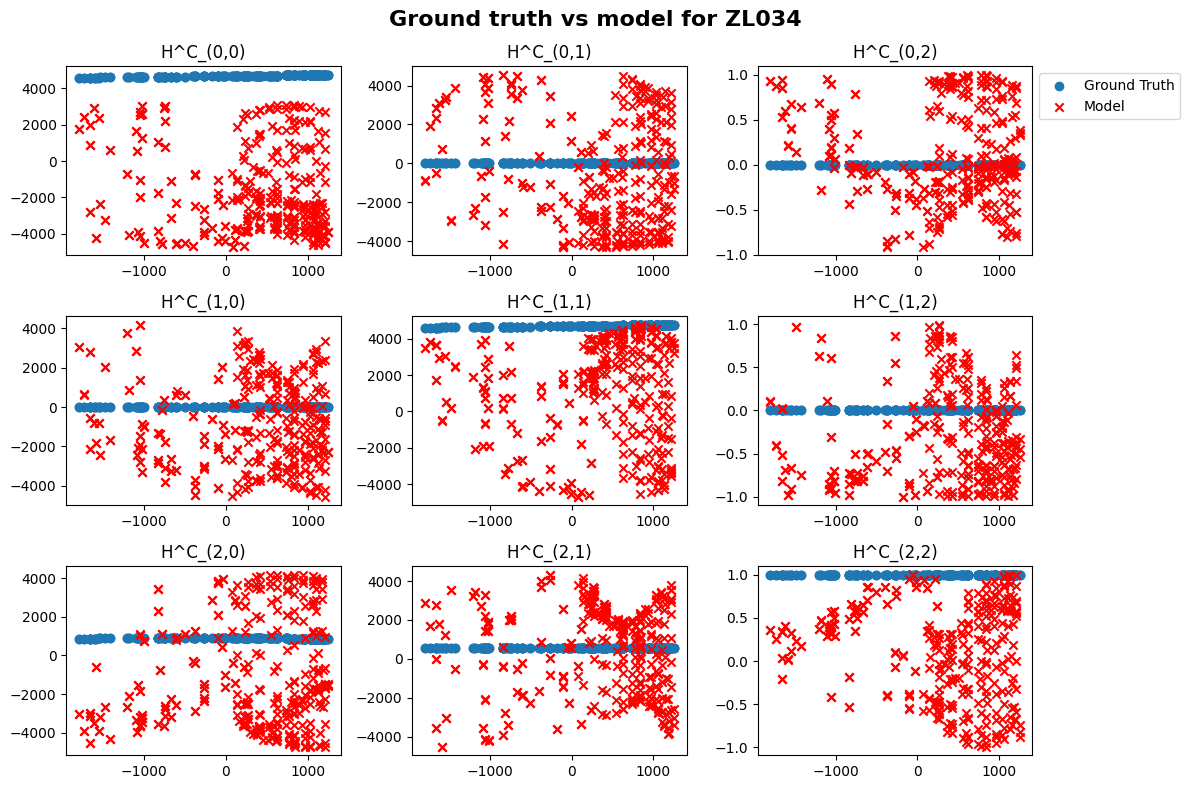

In [20]:
# See how well the above fit is

q_rrp = np.array(res.x[:4])

q_cm_zl_a = np.array(res.x[4:8])
q_cm_zl_b = np.array(res.x[8:12])

q_cm_zr_a = np.array(res.x[12:16])
q_cm_zr_b = np.array(res.x[16:20])


# Compute H_r from model
H_c_model = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C_({r},{c})")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

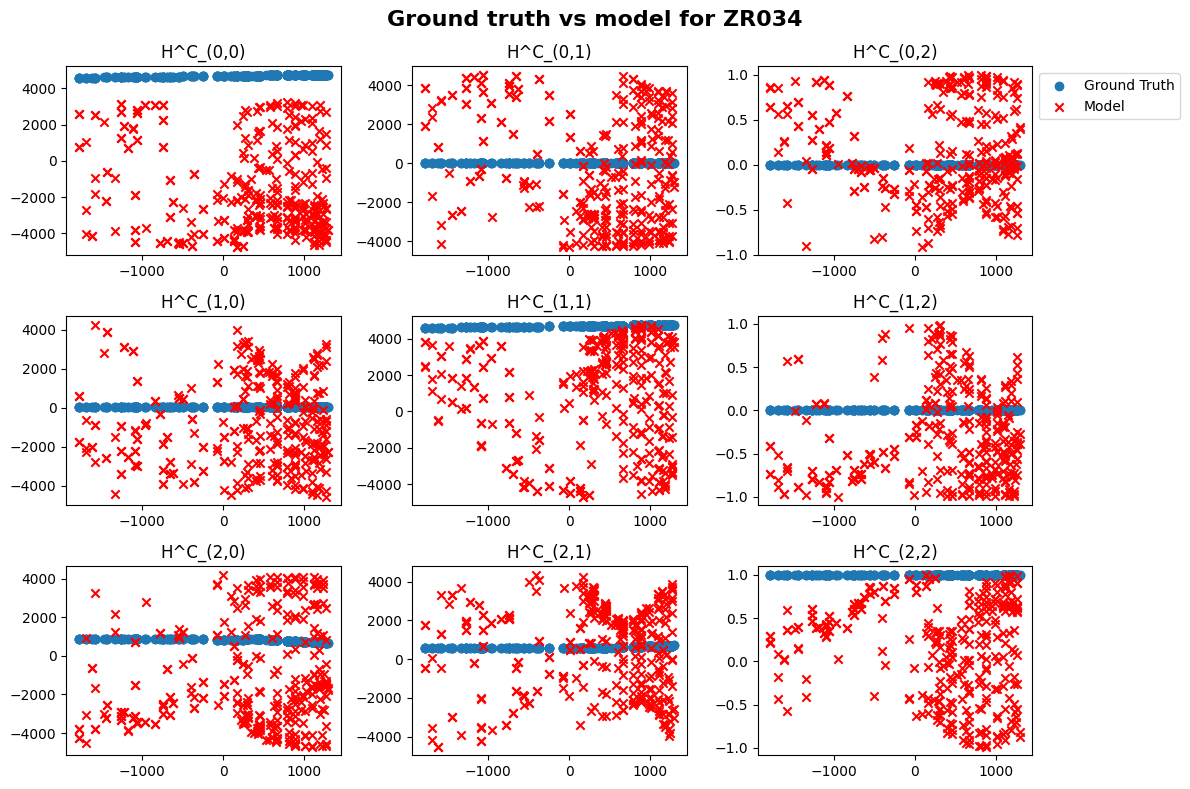

In [21]:
# Compute H_r from model
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C_({r},{c})")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

In [22]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

# Equality constraints
eq_constr = []
for i in range(data034.shape[0]):
  H_r = get_H_r_data(i, data034)
  if data034["cam"][i] == "ZL034":
    fun = lambda x: R.from_quat(get_q_rc_model(*x[:4], *x[4:8], *x[8:12], i, data034)).as_matrix()[0,:] @ H_r[:,1]
    

NameError: name 'Hr__r' is not defined

# learn a single rotation $R^r_c$

In [36]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  d = np.arccos(2 * (np.dot(q1, q2)**2) - 1)
  
  return d

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_l_0, q_rrp_l_1, q_rrp_l_2, q_rrp_l_3 = x[4:]
  q_rrp_r_0, q_rrp_r_1, q_rrp_r_2, q_rrp_r_3 = x[4:]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      total_dist += dist_q(q_rc_data, np.array([q_rrp_l_0, q_rrp_l_1, q_rrp_l_2, q_rrp_l_3]))
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      total_dist += dist_q(q_rc_data, np.array([q_rrp_r_0, q_rrp_r_1, q_rrp_r_2, q_rrp_r_3]))
      count += 1
  
  return total_dist/count

x0 = [0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5]
res = minimize(obj, x0, method="BFGS", options={"return_all":True})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{res.x[:4]/np.linalg.norm(res.x[:4])}")
print(f"q_cm_zl_a:{res.x[4:8]/np.linalg.norm(res.x[4:8])}")
print(f"q_cm_zl_b:{res.x[8:12]/np.linalg.norm(res.x[8:12])}")
print(f"q_cm_zr_a:{res.x[12:16]/np.linalg.norm(res.x[12:16])}")
print(f"q_cm_zr_b:{res.x[16:20]/np.linalg.norm(res.x[16:20])}")

Final function:1.554637
Final Jacobian:0.000012
q_rrp:[ 0.5  0.5  0.5 -0.5]
q_cm_zl_a:[-0.45238874 -0.1415942  -0.27217467 -0.83738668]
q_cm_zl_b:[]
q_cm_zr_a:[]
q_cm_zr_b:[]


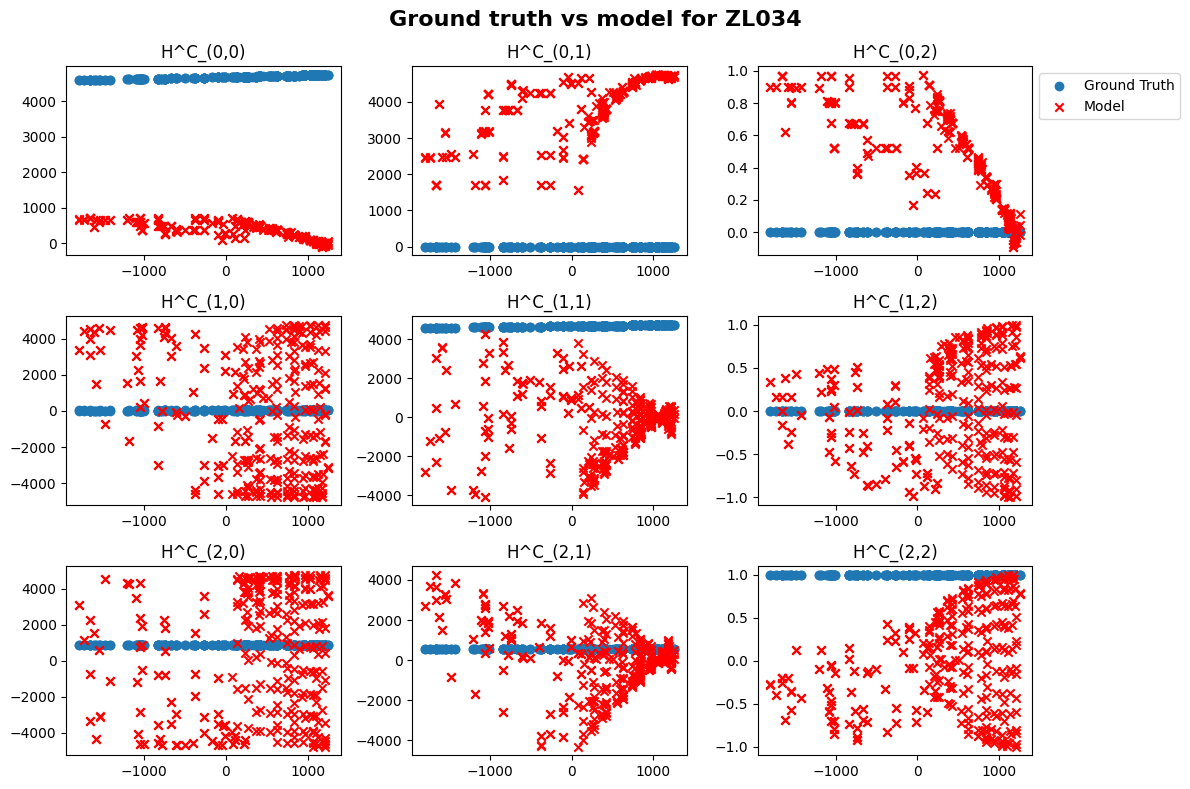

In [37]:
# Compute H_r from model
H_c_model = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

R_rc = R.from_quat(res.x[:4]).as_matrix()
for i in range(zl034.shape[0]):
  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C_({r},{c})")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

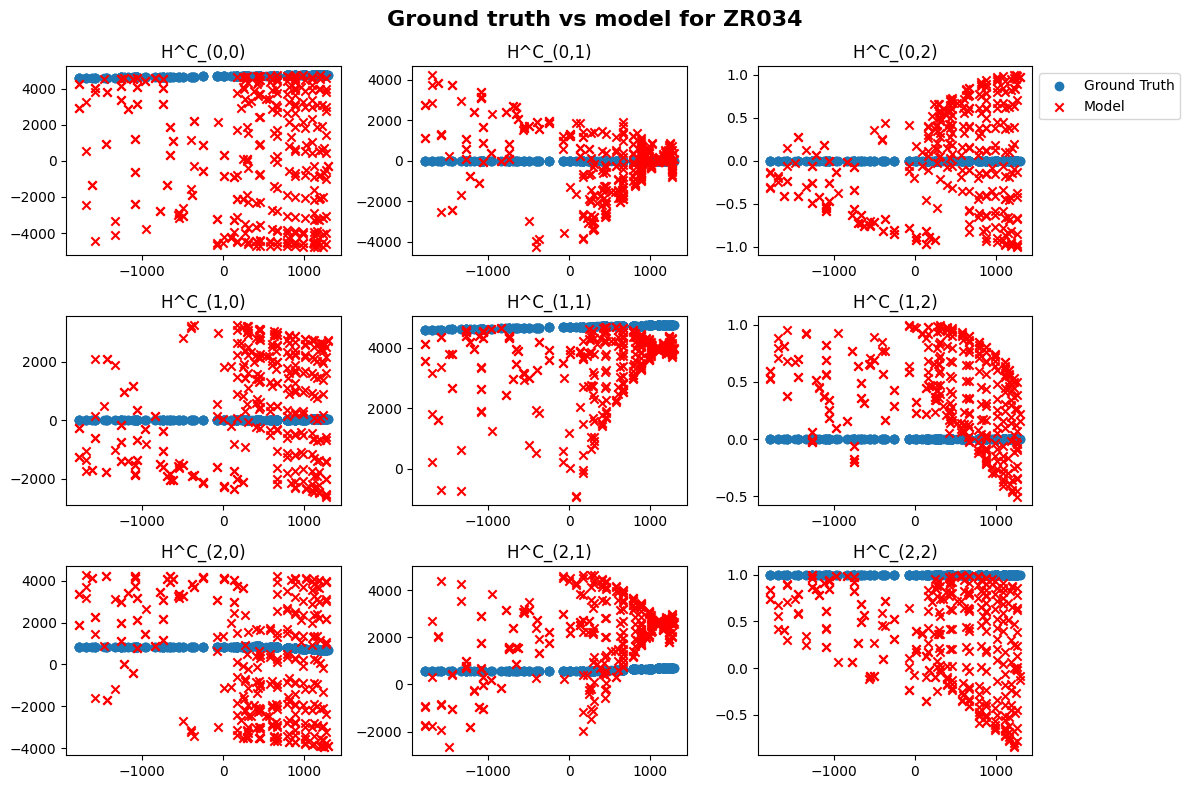

In [39]:
# Compute H_r from model
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

R_rc = R.from_quat(res.x[4:]).as_matrix()
for i in range(zr034.shape[0]):
  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H^C_({r},{c})")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

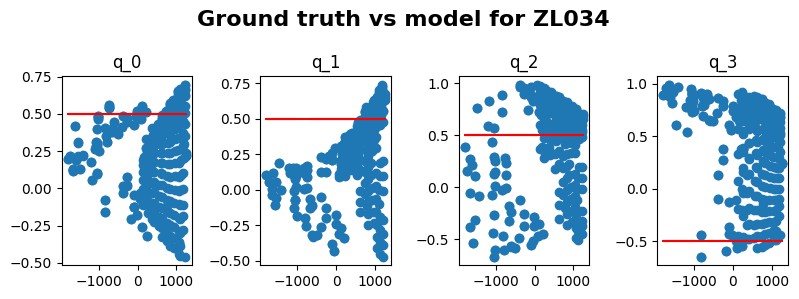

In [51]:
# plot the quaternion from model and data
q_data = []
for i in range(zl034.shape[0]):
  H_r = get_H_r_data(i, zl034)
  H_c_gt = get_KC(i, zl034).T
  R_rc_data = H_r @ np.linalg.inv(H_c_gt)

  q_data.append(R.from_matrix(R_rc_data).as_quat())

fig, ax = plt.subplots(1, 4, figsize=(8,3))
for i in range(4):
  ax[i].scatter(zl034["fmc"], [q[i] for q in q_data])
  ax[i].plot(zl034["fmc"], [res.x[i]]*zl034.shape[0], color="red")
  ax[i].set_title(f"q_{i}")

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

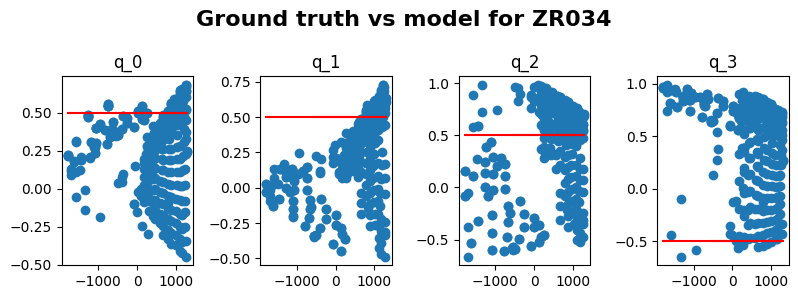

In [53]:
# plot the quaternion from model and data
q_data = []
for i in range(zr034.shape[0]):
  H_r = get_H_r_data(i, zr034)
  H_c_gt = get_KC(i, zr034).T
  R_rc_data = H_r @ np.linalg.inv(H_c_gt)

  q_data.append(R.from_matrix(R_rc_data).as_quat())

fig, ax = plt.subplots(1, 4, figsize=(8,3))
for i in range(4):
  ax[i].scatter(zr034["fmc"], [q[i] for q in q_data])
  ax[i].plot(zr034["fmc"], [res.x[i]]*zr034.shape[0], color="red")
  ax[i].set_title(f"q_{i}")

fig.suptitle("Ground truth vs model for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()